In [1]:
import pandas as pd
import os
import stats

# Obtain the true labels from the data

In [2]:
true_label, all_label, predictions, pred_probs = stats.get_true_labels("../data/New392.csv")

In [3]:
pre, rec, f1, roc, acc, true_m, pred_m, pred_m_auc =stats.get_eval_metrics(predictions, pred_probs, true_label, all_label)

In [4]:
print(pre, rec, f1, roc, acc, roc)

0.6757718906845605 0.8151093439363817 0.7049001609905515 0.9038717822211835 0.5408163265306123 0.9038717822211835


# CLEAN_contact

In [5]:
true_label_clean, all_label_clean, predictions_clean, pred_probs_clean = stats.get_true_labels_clean("../data/New392.csv")

In [6]:
pre_clean, rec_clean, f1_clean, roc_clean, acc_clean, true_m_clean, pred_m_clean, pred_m_auc_clean =stats.get_eval_metrics(predictions_clean, pred_probs_clean, true_label_clean, all_label_clean)

In [7]:
print(pre_clean, rec_clean, f1_clean, roc_clean, acc_clean, roc_clean)

0.6210238568588469 0.5745526838966203 0.5688518001755739 0.7858307280871066 0.5459183673469388 0.7858307280871066


# Plots

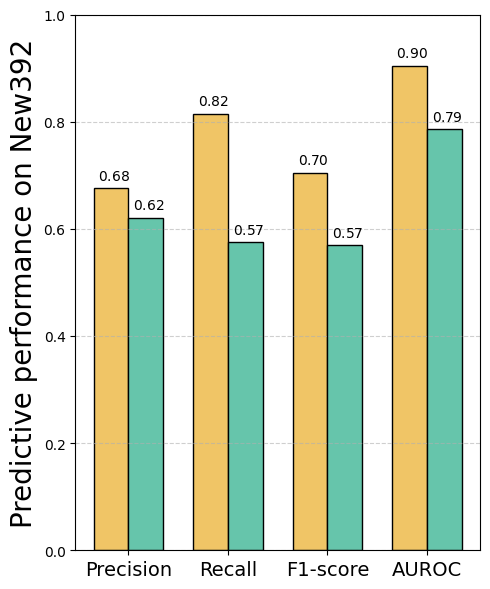

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Define your metrics and values
metrics = ['Precision', 'Recall', 'F1-score', 'AUROC']

# Replace these values with your actual data
clean_contact_scores = [pre_clean, rec_clean, f1_clean, roc_clean] 
actseekn_scores = [pre, rec, f1, roc]

# 2. Set up the positions for the bars
x = np.arange(len(metrics))  # The label locations
width = 0.35  # The width of the bars

# 3. Create the plot
fig, ax = plt.subplots(figsize=(5, 6))

color_1 = '#66C5AB' # Dark Blue
color_2 = '#F0C566' # Vermillion/Orange

# Add bars for each method
rects1 = ax.bar(x - width/2, actseekn_scores, width, label='ActSeekN',color=color_2, edgecolor='black')
rects2 = ax.bar(x + width/2, clean_contact_scores, width, label='CLEAN-contact', color=color_1, edgecolor='black')


# 4. Add labels, title, and legend
ax.set_ylabel('Predictive performance on New392', fontsize=20)
#ax.set_title('Comparison of CLEAN-contact and ActSeekN Performance')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=14)
ax.set_ylim(0, 1.0) # Sets Y-axis from 0 to 1 (with some padding)
#ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.6)
# 5. Add text labels on top of the bars for clarity
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'${height:.2f}$',
                    xy=((rect.get_x() + rect.get_width() /2)+0.03, height),
                    xytext=(0, 4),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()

# 6. Save or show the plot
plt.savefig('../figures/performance_comparison_new39.pdf', 
            dpi=600, 
            bbox_inches='tight', 
            transparent=False)
plt.show()